In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from requests import head
import seaborn as sns

all_data = pd.read_parquet("all_features.parquet")
all_data.head(30)

,customer_id,customer_type,label,cash_value_ratio,emt_velocity_monthly_mean,income_transaction_gap_score,is_retired,is_unemployed,occupation_sector_id,spending_income_ratio,...,msb_net_retention_ratio,struct_total_near_n,struct_days_with_near,struct_max_near_in_day,struct_total_near_sum,tx_country_n,tx_province_n,tx_city_n,pct_tx_province_mismatch,pct_tx_city_mismatch
0,SYNID0100000167,IND,NaN,0.000000,0.000000,0.807090,0.0,0.0,2.0,0.000000,...,0.706175,0,0,0,0.00,0,0,0,1.000000,1.000000
1,SYNID0100000431,IND,NaN,0.183417,9.333333,NaN,0.0,0.0,18.0,NaN,...,-0.291106,0,0,0,0.00,1,7,21,1.000000,0.750000
2,SYNID0100000485,IND,0.0,0.037841,0.000000,1.460746,1.0,0.0,18.0,0.234281,...,0.328867,0,0,0,0.00,1,6,13,0.750000,0.975000
3,SYNID0100000539,IND,NaN,0.000000,3.500000,0.016742,1.0,0.0,18.0,0.863900,...,-0.968301,0,0,0,0.00,5,10,40,1.000000,0.673333
4,SYNID0100000932,IND,NaN,0.012255,1.000000,17.062930,1.0,0.0,18.0,1.579105,...,0.661526,0,0,0,0.00,2,12,40,0.598174,0.926941
5,SYNID0100001185,IND,NaN,0.009489,0.000000,1.145784,0.0,1.0,17.0,0.038706,...,0.604975,0,0,0,0.00,1,5,5,0.956522,0.956522
6,SYNID0100001300,IND,NaN,0.000000,7.333333,0.667736,1.0,0.0,18.0,2.544130,...,-0.697048,0,0,0,0.00,2,12,39,0.923077,0.989011
7,SYNID0100001310,IND,NaN,0.000000,0.000000,0.112450,0.0,0.0,18.0,0.035213,...,0.229794,0,0,0,0.00,1,4,4,1.000000,0.750000
8,SYNID0100001952,IND,NaN,0.000000,7.000000,NaN,0.0,0.0,18.0,NaN,...,0.264612,0,0,0,0.00,1,6,7,0.835821,1.000000
9,SYNID0100002045,IND,NaN,0.000000,0.000000,0.578450,1.0,0.0,18.0,0.369520,...,-0.347166,0,0,0,0.00,1,10,36,0.623932,0.991453


- Semi-supervised Self-Training Autoencoder (customer-level suspiciousness)

- Use label == 0 as seed “normal” customers.

- Train an autoencoder to reconstruct normal feature patterns.

- Score all customers by reconstruction error (higher = more anomalous).

- Self-training step (semi-supervised): from the unlabeled pool, add the lowest-error customers into the normal training set, retrain, and then score again.

- Output: a ranked list of customers with an anomaly score

In [5]:
# =========================================
# 0. Imports
# =========================================

from sklearn.model_selection import train_test_split    
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


In [6]:
# =========================================
# 1. Basic setup: split columns and define "seed normals"
# =========================================
df = all_data.copy()

ID_COLS = ["customer_id"]
LABEL_COL = "label"

# Keep label for splitting; drop ID from features
y = df[LABEL_COL]
X = df.drop(columns=ID_COLS + [LABEL_COL], errors="ignore")

# Seed normal set: confirmed normal customers
seed_normal_mask = (y == 0)

# Unlabeled pool (most of your data)
unlabeled_mask = y.isna()

print("Seed normals:", seed_normal_mask.sum())
print("Unlabeled:", unlabeled_mask.sum())
print("Total:", len(df))


Seed normals: 990
Unlabeled: 60410
Total: 61410


In [7]:
# =========================================
# 2. Preprocessing
# =========================================
# Identify categorical vs numeric columns
cat_cols = [c for c in X.columns if str(X[c].dtype) in ["object", "category"]]
num_cols = [c for c in X.columns if c not in cat_cols]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler(with_centering=True)) # RobustScaler is safer for heavy-tailed AML features like ratios, counts, gaps
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

# Fit preprocess ONLY on seed normals to avoid leaking anomaly patterns into scaling
X_seed = X.loc[seed_normal_mask]
preprocess.fit(X_seed)

X_seed_t = preprocess.transform(X_seed)
X_all_t  = preprocess.transform(X)

print("Transformed shape:", X_all_t.shape)


Transformed shape: (61410, 50)


/Users/annie/Desktop/Code/IMI_Case_Codes/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['kurt_debit' 'kurt_credit']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/annie/Desktop/Code/IMI_Case_Codes/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['kurt_debit' 'kurt_credit']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/annie/Desktop/Code/IMI_Case_Codes/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['kurt_debit' 'kurt_credit']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [8]:
# =========================================
# 3. Define a small Autoencoder (dense, tabular)
# =========================================
class AutoEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, bottleneck_dim=16, dropout=0.1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, bottleneck_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

def train_ae(X_train_np, epochs=25, batch_size=512, lr=1e-3, weight_decay=1e-5, verbose=True):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    X_train = torch.tensor(X_train_np, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_train), batch_size=batch_size, shuffle=True, drop_last=False)

    model = AutoEncoder(input_dim=X_train_np.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss(reduction="mean")

    model.train()
    for ep in range(1, epochs + 1):
        losses = []
        for (xb,) in loader:
            xb = xb.to(device)
            opt.zero_grad()
            recon = model(xb)
            loss = loss_fn(recon, xb)
            loss.backward()
            opt.step()
            losses.append(loss.item())
        if verbose and (ep % 5 == 0 or ep == 1):
            print(f"Epoch {ep:02d} | loss={np.mean(losses):.6f}")
    return model

@torch.no_grad()
def reconstruction_error(model, X_np):
    device = next(model.parameters()).device
    X_t = torch.tensor(X_np, dtype=torch.float32).to(device)
    model.eval()
    recon = model(X_t)
    # per-row mean squared error
    mse = torch.mean((recon - X_t) ** 2, dim=1).detach().cpu().numpy()
    return mse


In [9]:
# =========================================
# 4. Semi-supervised self-training loop
#    (expand normal set using low-error unlabeled points)
# =========================================
X_seed_np = X_seed_t.astype(np.float32)
X_unlab_np = X_all_t[unlabeled_mask.values].astype(np.float32)

# Step A: train on seed normals
ae0 = train_ae(X_seed_np, epochs=25, verbose=True)

# Step B: score unlabeled; add "most normal" from unlabeled into normal training
unlab_scores0 = reconstruction_error(ae0, X_unlab_np)

# Heuristic: take the 30% of unlabeled with lowest reconstruction error as "likely normal"
q = 0.30   # 30% most-normal unlabeled
threshold_q = np.quantile(unlab_scores0, q)
likely_normal_unlab = X_unlab_np[unlab_scores0 <= threshold_q]

print("Likely-normal unlabeled added:", likely_normal_unlab.shape[0])

# Step C: retrain AE on expanded normal data
X_expanded = np.vstack([X_seed_np, likely_normal_unlab])
ae1 = train_ae(X_expanded, epochs=25, verbose=True)

# Final scoring for ALL customers
all_scores = reconstruction_error(ae1, X_all_t.astype(np.float32))

df_scores = df[["customer_id", "customer_type"]].copy()
df_scores["anomaly_score"] = all_scores

df_scores.sort_values("anomaly_score", ascending=False).head(10)


Epoch 01 | loss=396022.320312
Epoch 05 | loss=375039.234375
Epoch 10 | loss=349879.632812
Epoch 15 | loss=302801.703125
Epoch 20 | loss=229051.015625
Epoch 25 | loss=166090.937500
Likely-normal unlabeled added: 18123
Epoch 01 | loss=19764.621377
Epoch 05 | loss=6487.816057
Epoch 10 | loss=1655.767174
Epoch 15 | loss=981.593461
Epoch 20 | loss=1318.501656
Epoch 25 | loss=745.873382


,customer_id,customer_type,anomaly_score
1766,SYNID0100340845,IND,6.079847e+09
20642,SYNID0103893826,IND,3.015890e+09
32431,SYNID0106084824,IND,1.654393e+09
22775,SYNID0104304053,IND,1.548650e+09
18582,SYNID0103498635,IND,1.157103e+09
45578,SYNID0108548082,IND,1.045923e+09
3498,SYNID0100662953,IND,9.544257e+08
46523,SYNID0108730304,IND,8.086587e+08
34472,SYNID0106479004,IND,7.489208e+08
24599,SYNID0104632267,IND,6.708851e+08


In [10]:
# =========================================
# 5. Turn anomaly scores into alerts
# =========================================
# Alert top p% highest scores
p = 0.01  # 1% alerts (adjust this threshold based on your investigation capacity)
alert_cut = np.quantile(df_scores["anomaly_score"], 1 - p)

df_scores["is_alert"] = (df_scores["anomaly_score"] >= alert_cut).astype(int)

print("Alerts:", df_scores["is_alert"].sum())
df_scores[df_scores["is_alert"] == 1].sort_values("anomaly_score", ascending=False).head(20)


Alerts: 615


,customer_id,customer_type,anomaly_score,is_alert
1766,SYNID0100340845,IND,6.079847e+09,1
20642,SYNID0103893826,IND,3.015890e+09,1
32431,SYNID0106084824,IND,1.654393e+09,1
22775,SYNID0104304053,IND,1.548650e+09,1
18582,SYNID0103498635,IND,1.157103e+09,1
45578,SYNID0108548082,IND,1.045923e+09,1
3498,SYNID0100662953,IND,9.544257e+08,1
46523,SYNID0108730304,IND,8.086587e+08,1
34472,SYNID0106479004,IND,7.489208e+08,1
24599,SYNID0104632267,IND,6.708851e+08,1


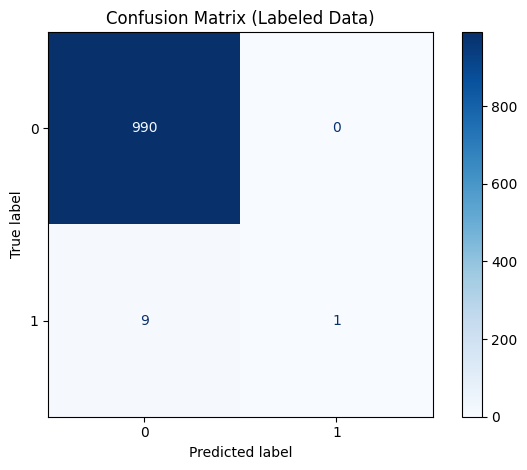

In [11]:
# =========================================
# 6. Confusion matrix on labeled data
# =========================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labeled_mask = df[LABEL_COL].notna()
y_true = df.loc[labeled_mask, LABEL_COL].astype(int)
y_pred = df_scores.loc[labeled_mask, "is_alert"].astype(int)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Labeled Data)")
plt.tight_layout()
plt.show()